# Exploring the effect of Remote Work on Salary

## 1. Business Understanding

To be revisited...

## 2. Data Understanding — Exploratory Data Analysis

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://github.com/StackExchange/Survey/blob/main/packages/archive/2025/results.csv?raw=true'

df = pd.read_csv(url, low_memory=False)

In [146]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), str(119)
memory usage: 64.6 MB


In [147]:
df.shape

(49191, 172)

In [148]:
df.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


### Principal Component Analysis

In [149]:
# Narrowing the dataset to the two features of importance, plus the ResponseId column to keep track of the respondents. 
# I will also make a copy of the dataframe to avoid any SettingWithCopyWarning errors.

cols = ['RemoteWork', 'ConvertedCompYearly']
data = df[cols].copy()

print(data.shape)
data.head()

(49191, 2)


,RemoteWork,ConvertedCompYearly
0,Remote,61256.0
1,"Hybrid (some in-person, leans heavy to flexibi...",104413.0
2,NaN,53061.0
3,Remote,36197.0
4,NaN,60000.0


In [150]:
data.isnull().sum()

RemoteWork             15411
ConvertedCompYearly    25244
dtype: int64

### Salary Distribution

In [151]:
data["ConvertedCompYearly"].describe()

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

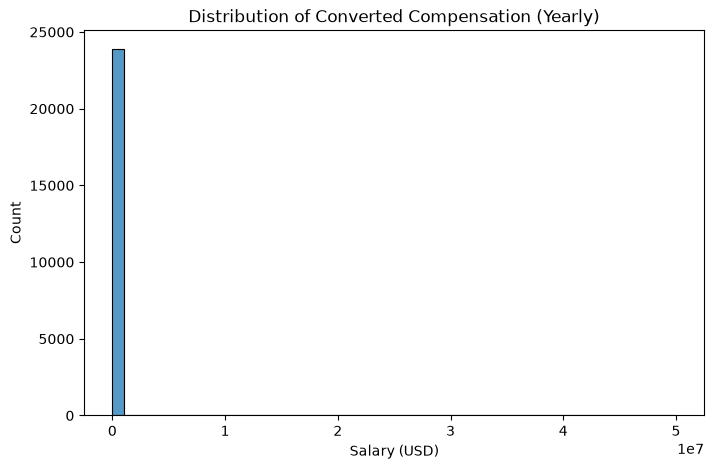

In [152]:
plt.figure(figsize=(8,5))
sns.histplot(data['ConvertedCompYearly'].dropna(), bins=50)
plt.title('Distribution of Converted Compensation (Yearly)')
plt.xlabel('Salary (USD)')
plt.show()

#### Observations

The distribution of `ConvertedCompYearly` is highly right-skewed, with a long tail of extreme high values. Most entries cluster at lower salary values, while a small number of outliers pull the mean well above the median. This skew would distort any model that assumes normally distributed errors (like linear regression), so I applied a log transformation to `ConvertedCompYearly` to aid proper visualization and further analysis.

### Log transformation of `ConvertedCompYearly`

In [153]:
data['LogSalary'] = np.log1p(data['ConvertedCompYearly'])


In [154]:
data["LogSalary"].describe()

count    23947.000000
mean        10.847896
std          1.570676
min          0.693147
25%         10.549858
50%         11.229514
75%         11.700210
max         17.727534
Name: LogSalary, dtype: float64

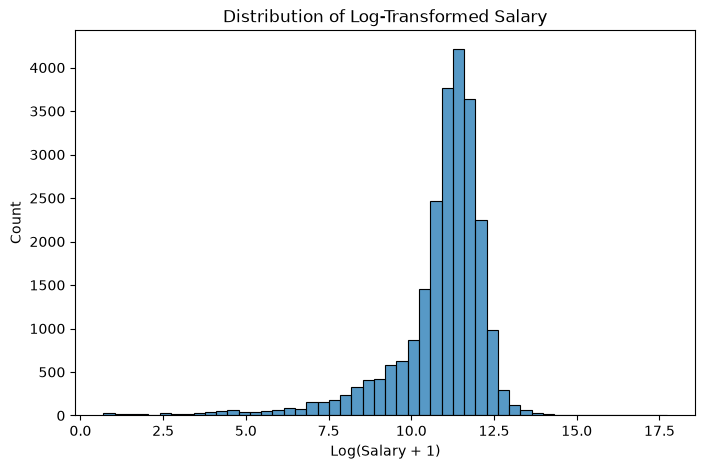

In [155]:

# Plotting `LogSalary` distribution

plt.figure(figsize=(8,5))
sns.histplot(data['LogSalary'].dropna(), bins=50)
plt.title('Distribution of Log-Transformed Salary')
plt.xlabel('Log(Salary + 1)')
plt.show()

### `RemoteWork` Value Counts

In [156]:
data['RemoteWork'].value_counts(dropna=False)

RemoteWork
NaN                                                                             15411
Remote                                                                          10931
Hybrid (some remote, leans heavy to in-person)                                   6732
In-person                                                                        6042
Hybrid (some in-person, leans heavy to flexibility)                              5831
Your choice (very flexible, you can come in when you want or just as needed)     4244
Name: count, dtype: int64

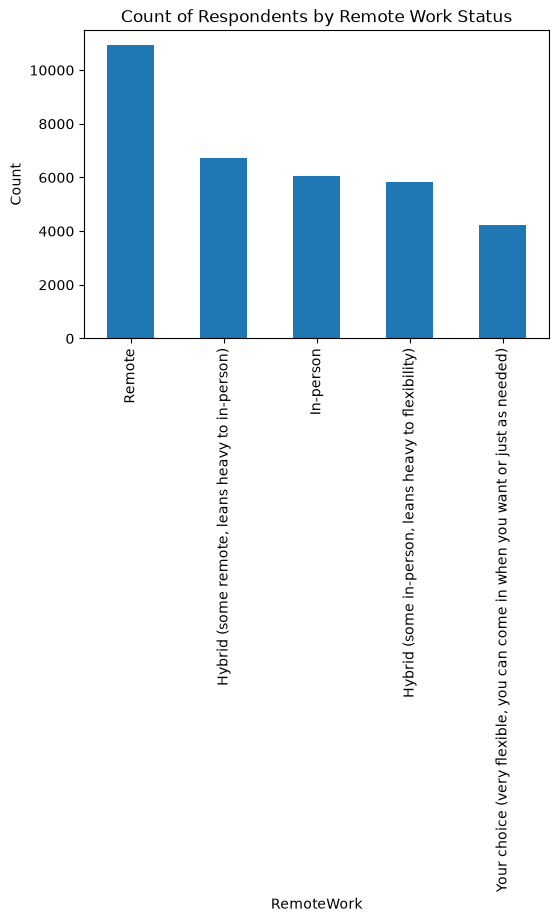

In [157]:
plt.figure(figsize=(6,4))
data['RemoteWork'].value_counts().plot(kind='bar')
plt.title('Count of Respondents by Remote Work Status')
plt.ylabel('Count')
plt.show()

### `LogSalary` v. `RemoteWork` Analysis

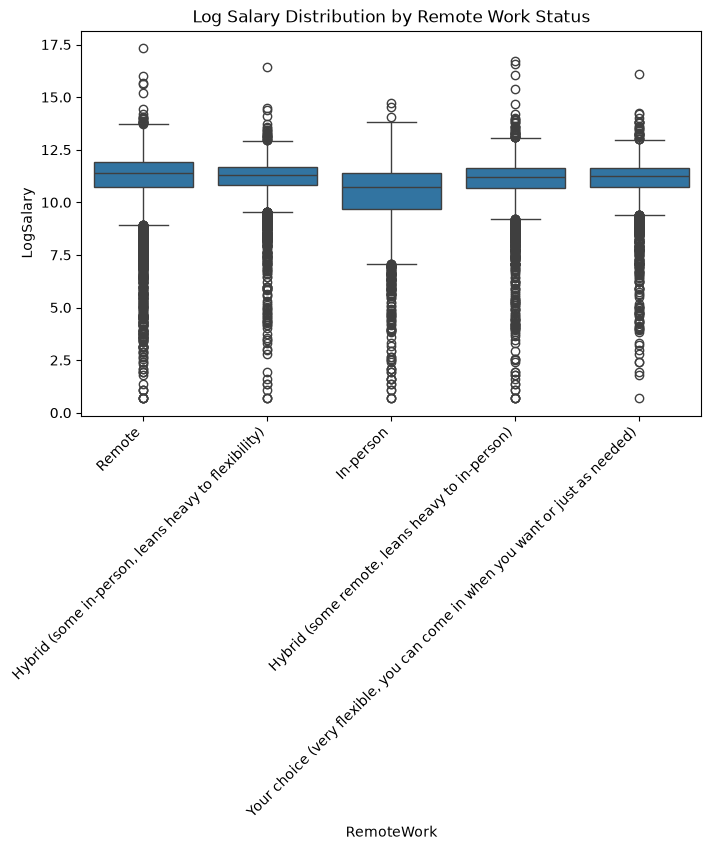

In [158]:
# LogSalary is used in place of ConvertedCompYearly to normalize the distribution and make it easier to visualize and analyze the trends between both.

plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='RemoteWork', y='LogSalary')
plt.title('Log Salary Distribution by Remote Work Status')
plt.xticks(rotation=45, ha='right')
plt.show()

### Summary Statistics By Group

In [159]:
data.groupby('RemoteWork')['LogSalary'].describe()

,count,mean,std,min,25%,50%,75%,max
RemoteWork,,,,,,,,
"Hybrid (some in-person, leans heavy to flexibility)",3815.0,11.052481,1.223528,0.693147,10.816090,11.301797,11.661483,16.448964
"Hybrid (some remote, leans heavy to in-person)",4203.0,10.929946,1.394031,0.693147,10.668711,11.197653,11.649862,16.727184
In-person,3199.0,10.367142,1.654672,0.693147,9.680250,10.745206,11.415821,14.731802
Remote,7126.0,11.008766,1.566909,0.693147,10.720968,11.390679,11.918397,17.328628
"Your choice (very flexible, you can come in when you want or just as needed)",2753.0,10.955572,1.346934,0.693147,10.744925,11.230708,11.633008,16.118096


### Summary of Exploratory Findings

After narrowing the dataset to `RemoteWork` and `ConvertedCompYearly`, I found substantial missingness: 15,411 missing values in RemoteWork and 25,244 missing values in `ConvertedCompYearly`. I also observed extreme outliers in `ConvertedCompYearly`, along with severe right skew. To make the data usable for visualization and modeling, I applied a log transformation (log1p) to `ConvertedCompYearly`, which produced a more interpretable, roughly normal distribution.

`RemoteWork` comprises five categories. The majority of entries were fully Remote (10,931), followed by two Hybrid variants (6,732 leaning in-person, 5,831 leaning flexible), In-person (6,042), and a smaller "your choice" flexible category (4,244). 

The boxplot of log-transformed salary by remote work status shows that In-person workers have a visibly lower median salary than the other four categories, which cluster closely together. However, all `RemoteWork` categories show a large number of low-end outliers. This suggests the data may contain unrealistic or low-quality salary entries (e.g. near-zero values, part-time or student respondents) that should be filtered out during data preparation, in addition to the high-end outliers already noted.

Given the missingness and outliers, the data clearly requires cleaning before modeling. Next, I will: (1) drop rows missing RemoteWork and/or `ConvertedCompYearly`, and (2) address the remaining outliers in the salary data.

## 3. Data Preparation

### Dropping Null Values

In [160]:
# Dropping null values from the dataset to ensure that the analysis is based on complete cases only. 
# This is to avoid any biases or inaccuracies in the results.

before_outlier_removal = data.shape[0]
data = data.dropna()

### Applying Quantile-based Outlier Filtering

In [161]:
Q1 = data['LogSalary'].quantile(0.25) # First quartile
Q3 = data['LogSalary'].quantile(0.75) # Third quartile
IQR = Q3 - Q1 # Interquartile range

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[(data["LogSalary"] >= lower_bound) & (data["LogSalary"] <= upper_bound)] # This is the subset of data we want to keep
after_outlier_removal = len(data)

In [162]:
data.shape
print(f"Rows before: {before_outlier_removal}, Rows after: {after_outlier_removal}, Removed: {before_outlier_removal - after_outlier_removal}")

Rows before: 49191, Rows after: 19246, Removed: 29945


In [163]:
data.head()

,RemoteWork,ConvertedCompYearly,LogSalary
0,Remote,61256.0,11.022833
1,"Hybrid (some in-person, leans heavy to flexibi...",104413.0,11.556119
3,Remote,36197.0,10.496759
7,Remote,72000.0,11.184435
8,Remote,70000.0,11.156265


In [164]:
# Recomputing the descriptive statistics for LogSalary after removing outliers to see how the distribution has changed.

data["LogSalary"].describe()

count    19246.000000
mean        11.227300
std          0.786484
min          8.927049
25%         10.793989
50%         11.304806
75%         11.756789
max         13.377007
Name: LogSalary, dtype: float64

In [165]:
data.groupby('RemoteWork')['LogSalary'].describe()

,count,mean,std,min,25%,50%,75%,max
RemoteWork,,,,,,,,
"Hybrid (some in-person, leans heavy to flexibility)",3615.0,11.253269,0.686353,8.930230,10.906286,11.318989,11.686593,13.304687
"Hybrid (some remote, leans heavy to in-person)",3892.0,11.198969,0.749967,8.929435,10.793989,11.248048,11.661483,13.366222
In-person,2709.0,10.888097,0.896399,8.927580,10.277152,10.958287,11.512935,13.345344
Remote,6478.0,11.373692,0.797075,8.927049,10.958818,11.476795,11.931642,13.377007
"Your choice (very flexible, you can come in when you want or just as needed)",2552.0,11.222191,0.704470,8.949755,10.862991,11.293643,11.661483,13.304687


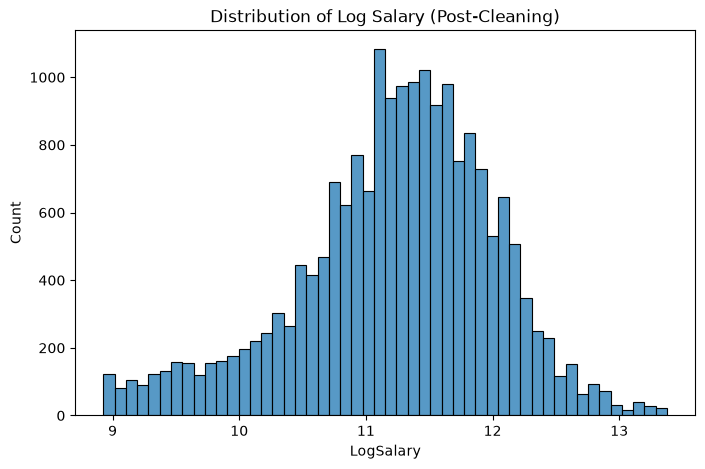

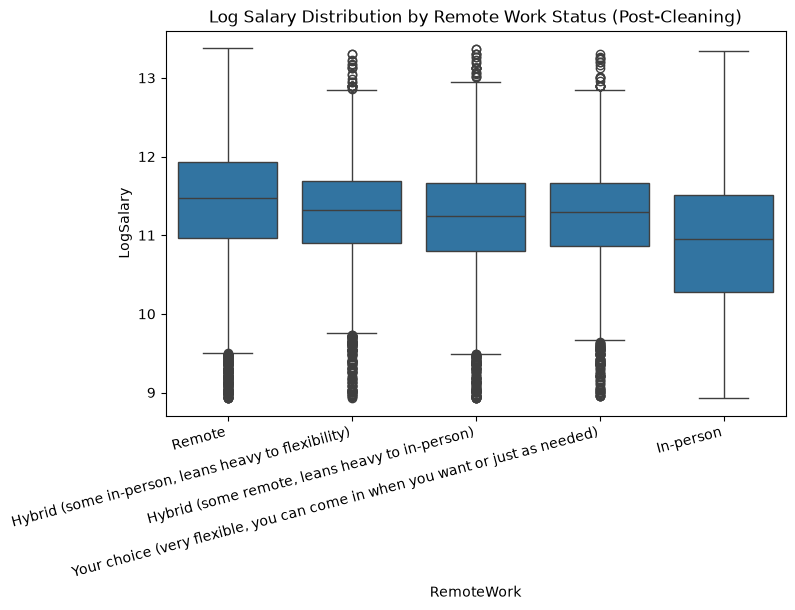

In [166]:
# Visualizing the distribution of LogSalary after removing outliers

plt.figure(figsize=(8,5))
sns.histplot(data['LogSalary'], bins=50)
plt.title('Distribution of Log Salary (Post-Cleaning)')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='RemoteWork', y='LogSalary')
plt.title('Log Salary Distribution by Remote Work Status (Post-Cleaning)')
plt.xticks(rotation=15, ha='right')
plt.show()

### Summary

I dropped rows with missing values in `RemoteWork` or `ConvertedCompYearly`, since these are the two core variables needed to answer the research question. Keeping rows with missing values in either column would introduce noise and bias into the analysis.

After transforming the target, I applied an IQR-based outlier filter to LogSalary. This method identifies the middle 50% of the data (between the 25th and 75th percentiles) and flags anything more than 1.5 times that range beyond either boundary as an outlier. I chose this approach over a fixed dollar threshold because it adapts to the spread of the data rather than relying on an arbitrary cutoff. This filter removed 1,850 rows (from 21,096 to 19,246, a reduction of 8.8%), eliminating extreme low and high salary values while preserving the core distribution.

After removing outliers, I re-plotted the distribution and boxplots and saw a clear improvement: the cloud of extreme low-end points from the original boxplots was now gone, and the salary distribution by RemoteWork category became much easier to read and compare across groups.

With missing values dropped, the target variable log-transformed, and outliers filtered, the dataset is now ready for modeling.

## 4. Modelling